<a href="https://colab.research.google.com/github/SmitPatil2004/traffic-forecasting-uct/blob/main/notebooks/03_traffic_modelling_ipynb_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Reload and rebuild

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
sns.set_style('whitegrid')

df = pd.read_csv('train_aWnotuB.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)

df['Hour']      = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Month']     = df['DateTime'].dt.month
df['Year']      = df['DateTime'].dt.year
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

TARGET = 'Vehicles'
cutoff = df['DateTime'].quantile(0.80)
train = df[df['DateTime'] <  cutoff].copy()
test  = df[df['DateTime'] >= cutoff].copy()

def scores(y, p):
    return mean_absolute_error(y, p), np.sqrt(mean_squared_error(y, p))

Step 2 — Investigate Junction 3

In [3]:
j3 = df[df['Junction'] == 3].copy()
j3['MonthPeriod'] = j3['DateTime'].dt.to_period('M')

print(j3.groupby('MonthPeriod')['Vehicles'].agg(['mean', 'max', 'count']).round(1))

             mean  max  count
MonthPeriod                  
2015-11       6.9   39    720
2015-12       4.2   21    744
2016-01       9.2   45    744
2016-02      12.4   71    696
2016-03      12.2  100    744
2016-04      16.0   65    720
2016-05      12.0   66    744
2016-06       8.0   19    720
2016-07      14.9  134    744
2016-08      12.8   97    744
2016-09      16.6   77    720
2016-10      15.7  103    744
2016-11      13.9  121    720
2016-12      14.0  102    744
2017-01      16.5  133    744
2017-02      18.9  180    672
2017-03      17.3   70    744
2017-04      21.6   96    720
2017-05      13.3   46    744
2017-06      18.0  162    720


In [4]:
spikes = j3[j3['Vehicles'] > 50]     # ~99th percentile is 51

print('Spike count:', len(spikes), 'out of', len(j3), 'rows')
print('\nBy hour of day:')
print(spikes['DateTime'].dt.hour.value_counts().sort_index())
print('\nBy day of week (0=Mon, 6=Sun):')
print(spikes['DateTime'].dt.dayofweek.value_counts().sort_index())

Spike count: 152 out of 14592 rows

By hour of day:
DateTime
0      8
1      1
9      1
10     3
11     4
12     2
13     1
14     3
15     2
16     4
17     3
18    11
19    21
20    42
21    29
22    10
23     7
Name: count, dtype: int64

By day of week (0=Mon, 6=Sun):
DateTime
0     1
1     6
2    15
3    26
4    17
5    62
6    25
Name: count, dtype: int64


Step 3 — Tuning

In [5]:
FEATURES = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'Year', 'IsWeekend']

configs = [
    {'n_estimators': 100},
    {'n_estimators': 300},
    {'n_estimators': 300, 'min_samples_leaf': 2},
    {'n_estimators': 300, 'min_samples_leaf': 5},
    {'n_estimators': 300, 'max_depth': 10},
]

results = []
for c in configs:
    m = RandomForestRegressor(random_state=42, n_jobs=-1, **c)
    m.fit(train[FEATURES], train[TARGET])
    mae, rmse = scores(test[TARGET], m.predict(test[FEATURES]))
    results.append({**c, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3)})

tuning = pd.DataFrame(results).sort_values('MAE')
tuning

,n_estimators,MAE,RMSE,min_samples_leaf,max_depth
3,300,4.736,7.781,5.0,NaN
2,300,4.761,7.824,2.0,NaN
1,300,4.802,7.879,NaN,NaN
0,100,4.809,7.890,NaN,NaN
4,300,4.944,7.940,NaN,10.0


Step 4 — Test extra features

In [6]:
df['DayOfMonth'] = df['DateTime'].dt.day
df['DayOfYear']  = df['DateTime'].dt.dayofyear

train = df[df['DateTime'] <  cutoff].copy()
test  = df[df['DateTime'] >= cutoff].copy()

BASE = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'Year', 'IsWeekend']

def evaluate(feats, label):
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                              random_state=42, n_jobs=-1)
    m.fit(train[feats], train[TARGET])
    mae, rmse = scores(test[TARGET], m.predict(test[feats]))
    print(f'{label:20} MAE {mae:.3f} | RMSE {rmse:.3f}')
    return m

evaluate(BASE, 'base')
evaluate(BASE + ['DayOfMonth'], '+ DayOfMonth')
evaluate(BASE + ['DayOfYear'], '+ DayOfYear')
evaluate(BASE + ['DayOfMonth', 'DayOfYear'], '+ both')

base                 MAE 4.736 | RMSE 7.781
+ DayOfMonth         MAE 5.217 | RMSE 8.609
+ DayOfYear          MAE 4.344 | RMSE 7.005
+ both               MAE 4.598 | RMSE 7.303


RandomForestRegressor(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                      random_state=42)

Step 5 — Train and evaluate the final model

In [7]:
FINAL = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'Year', 'IsWeekend', 'DayOfYear']

final_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                    random_state=42, n_jobs=-1)
final_model.fit(train[FINAL], train[TARGET])
test['Predicted'] = final_model.predict(test[FINAL])

mae, rmse = scores(test[TARGET], test['Predicted'])
print(f'Week 2 model: MAE 4.81 | RMSE 7.89')
print(f'Week 3 model: MAE {mae:.2f} | RMSE {rmse:.2f}')

Week 2 model: MAE 4.81 | RMSE 7.89
Week 3 model: MAE 4.34 | RMSE 7.01


Step 6 — Error distribution

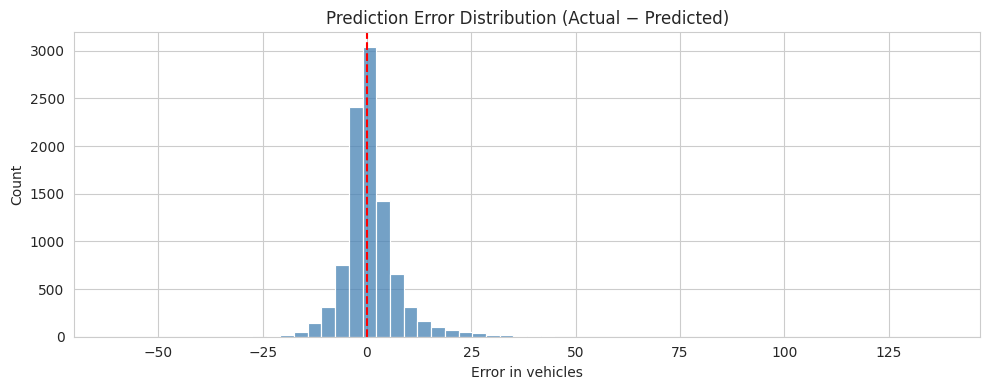

Within 5 vehicles:  72.6%
Within 10 vehicles: 90.4%
Average bias:       0.88


In [8]:
test['Error'] = test[TARGET] - test['Predicted']

plt.figure(figsize=(10, 4))
sns.histplot(test['Error'], bins=60, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Prediction Error Distribution (Actual − Predicted)')
plt.xlabel('Error in vehicles')
plt.tight_layout()
plt.savefig('07_error_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Within 5 vehicles: ', f"{(test['Error'].abs() <= 5).mean() * 100:.1f}%")
print('Within 10 vehicles:', f"{(test['Error'].abs() <= 10).mean() * 100:.1f}%")
print('Average bias:      ', round(test['Error'].mean(), 2))

Step 7 — Predicted vs actual, all four junctions

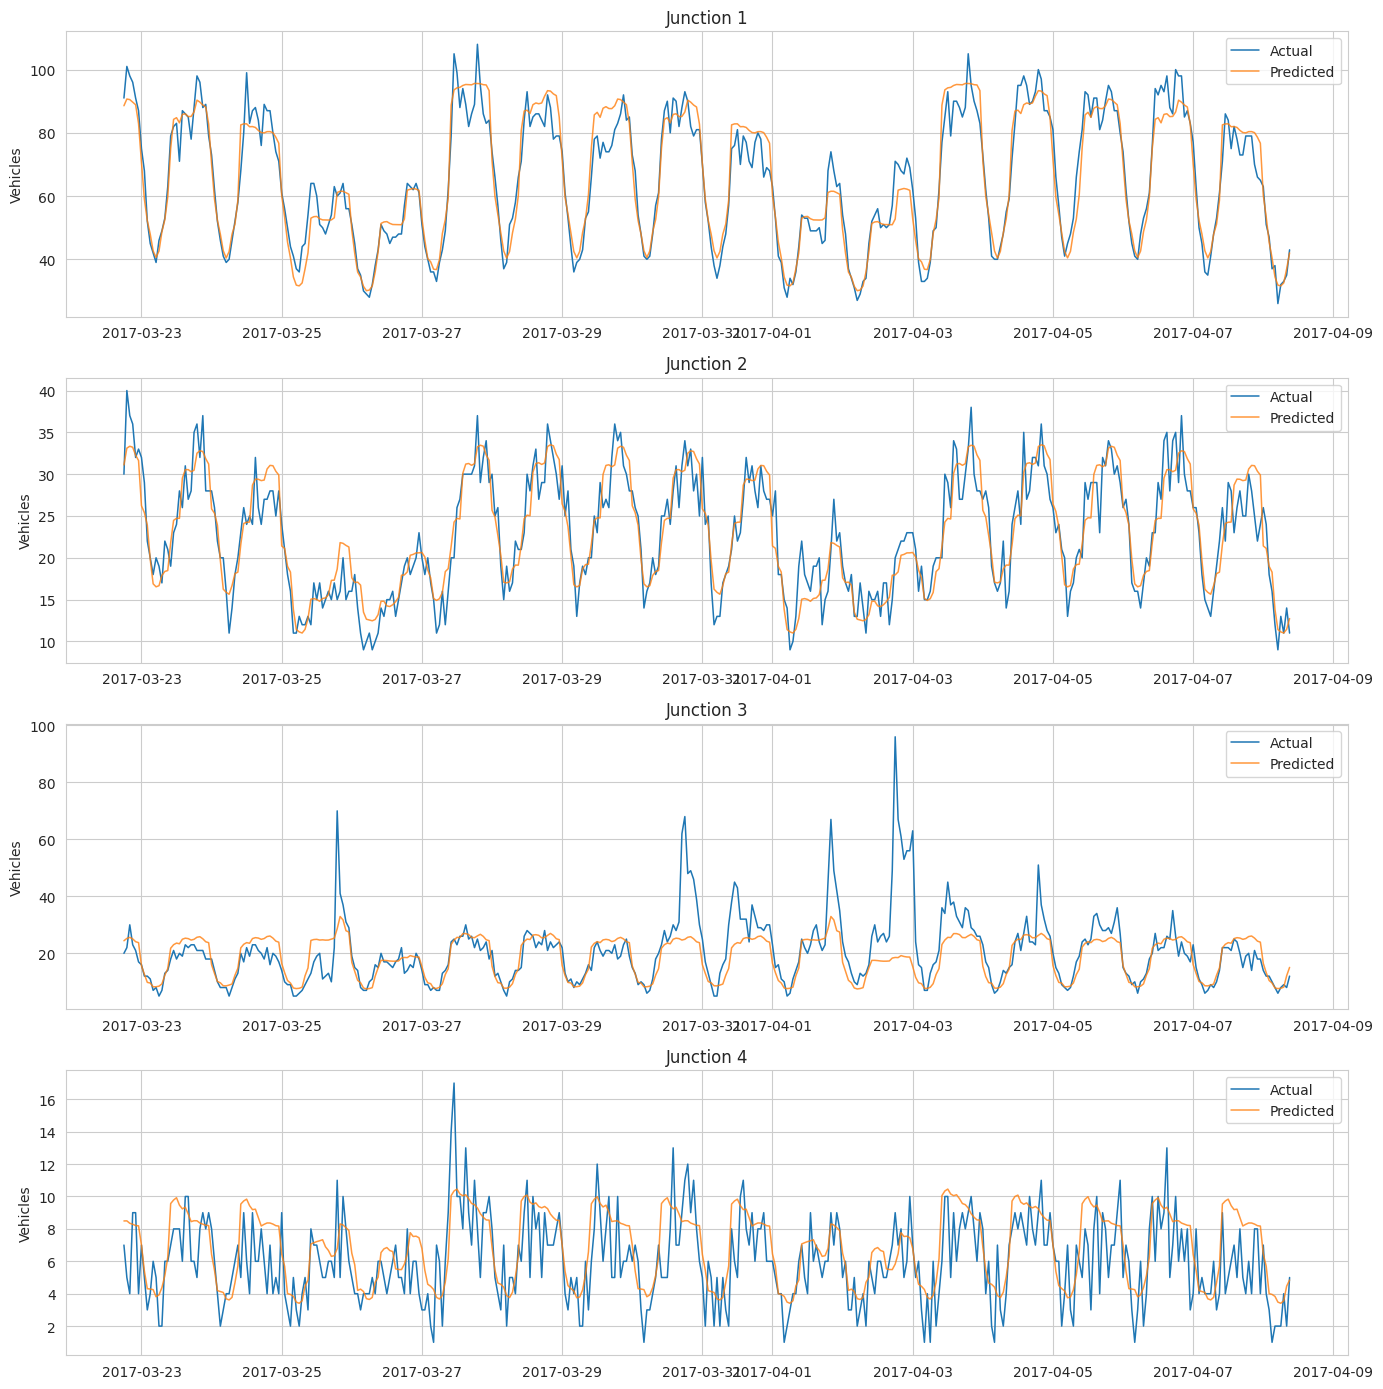

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

for ax, j in zip(axes, sorted(test['Junction'].unique())):
    s = test[test['Junction'] == j].sort_values('DateTime').head(400)
    ax.plot(s['DateTime'], s[TARGET], label='Actual', linewidth=1.1)
    ax.plot(s['DateTime'], s['Predicted'], label='Predicted', linewidth=1.1, alpha=0.8)
    ax.set_title(f'Junction {j}')
    ax.set_ylabel('Vehicles')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('08_pred_vs_actual_all.png', dpi=120, bbox_inches='tight')
plt.show()

Step 8 — Final feature importance

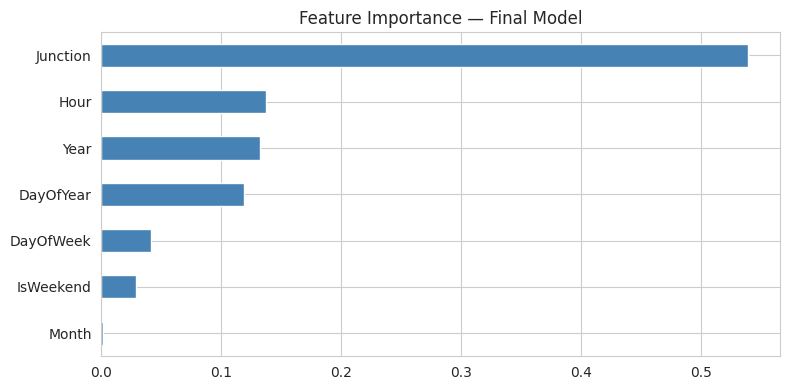

Junction     0.539
Hour         0.138
Year         0.132
DayOfYear    0.119
DayOfWeek    0.041
IsWeekend    0.029
Month        0.001
dtype: float64


In [10]:
imp = pd.Series(final_model.feature_importances_, index=FINAL).sort_values()

plt.figure(figsize=(8, 4))
imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Final Model')
plt.tight_layout()
plt.savefig('09_feature_importance_final.png', dpi=120, bbox_inches='tight')
plt.show()

print(imp.sort_values(ascending=False).round(3))